# ROMNICK M. CARLOS
# Environment: bioinformatics (Anaconda Environment)
# Python Version: 3.13.9
# Package/libraries version
    # NumPy: 2.3.5
    # Matplotlib: 3.10.6
    # h5py: 3.16.0
    # scikit-learn: 1.7.2

# Loading Dataset and CNN
*ROMNICK M. CARLOS*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (grayscale, resize, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Before you run this notebook:** download the Kaggle "Dogs vs. Cats" dataset (e.g. `https://www.kaggle.com/c/dogs-vs-cats/data` or the mirrored `salader/dogs-vs-cats` dataset on Kaggle) and unzip it so you have two folders, `Dog/` and `Cat/`, each full of `.jpg` images. Then set `DATADIR` below to point at the parent folder that contains `Dog/` and `Cat/`.

## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [1]:
# Run this once if the packages below aren't already installed.
# %pip install opencv-python numpy matplotlib tensorflow

## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [3]:
import zipfile
import os

# Path to the zip file in Google Drive

zip_file_path = "C:/Users/Victus/Desktop/Activity_01 bioinformatics python/PetImages.zip"

# Destination directory to unzip the files
destination_dir = "C:/Users/Victus/Desktop/Activity_01 bioinformatics python/"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# Update DATADIR to point to this unzipped location

Unzipped 'C:/Users/Victus/Desktop/Activity_01 bioinformatics python/PetImages.zip' to 'C:/Users/Victus/Desktop/Activity_01 bioinformatics python/'


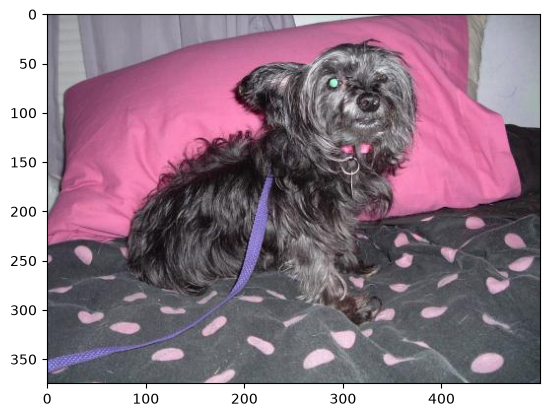

In [4]:
DATADIR = "C:/Users/Victus/Desktop/Activity_01 bioinformatics python/PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
# this is the directory of your datasets
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)  # path to cats or dogs dir
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # reading the image in the path and transforming it into a color array
        # cv2.IMREAD_COLOR loads all 3 color channels (BGR order), so the CNN
        # can learn from color information instead of just one grayscale channel

        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)  # convert BGR -> RGB so it previews correctly
        plt.imshow(img_array)  # no cmap='gray' — this is a color image now
        plt.show()
        break
    break

## Image Inspection

In [5]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[[117 115 126]
  [117 115 126]
  [119 117 130]
  ...
  [132 132 142]
  [131 131 141]
  [131 131 141]]

 [[118 116 127]
  [117 115 126]
  [119 117 130]
  ...
  [134 134 144]
  [133 133 143]
  [133 133 143]]

 [[119 117 128]
  [118 116 127]
  [120 118 131]
  ...
  [136 136 146]
  [135 135 145]
  [135 135 145]]

 ...

 [[ 75  80  84]
  [ 70  75  79]
  [ 69  74  78]
  ...
  [ 74  82  85]
  [ 70  78  81]
  [ 67  75  78]]

 [[ 74  79  83]
  [ 68  73  77]
  [ 65  70  74]
  ...
  [ 66  74  77]
  [ 67  75  78]
  [ 68  76  79]]

 [[ 70  75  79]
  [ 67  72  76]
  [ 66  71  75]
  ...
  [ 69  77  80]
  [ 67  75  78]
  [ 65  73  76]]]
(375, 500, 3)


## Image Resizing

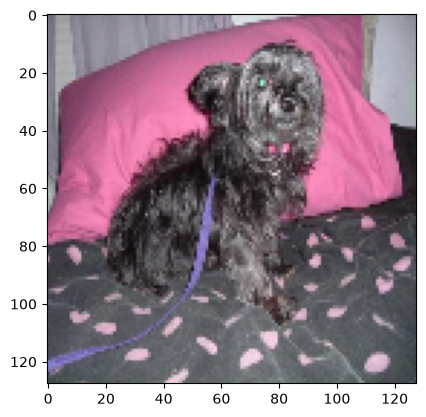

In [6]:
IMG_SIZE = 128 # initializing variable "IMG_SIZE" as 100

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

## Assigning Training Data

In [7]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)  # was cv2.IMREAD_GRAYSCALE
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()

## Checking the Number of Training Data

In [8]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [9]:
import random
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

0
0
0
1
0
0
0
0
1
1


## Assigning Variables for Features and Labels

In [10]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 3)  # 3 is for RGB
y = np.array(y)  # Keras expects the labels as an array too

## Using the Pickle Module

In [11]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [12]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[ 9, 14, 17],
        [12, 17, 20],
        [ 8, 13, 16],
        ...,
        [ 5,  9, 10],
        [ 5,  8, 11],
        [ 4,  7, 11]],

       [[ 8, 11, 15],
        [ 9, 12, 15],
        [ 8, 11, 15],
        ...,
        [ 0,  2,  3],
        [ 0,  1,  4],
        [ 0,  0,  4]],

       [[ 1,  3,  4],
        [ 1,  4,  4],
        [ 3,  5,  6],
        ...,
        [ 2,  4,  5],
        [ 1,  4,  5],
        [ 2,  4,  5]],

       ...,

       [[ 0, 12, 30],
        [ 0, 12, 30],
        [ 0, 11, 31],
        ...,
        [23, 25, 49],
        [20, 24, 49],
        [24, 28, 52]],

       [[ 2, 14, 32],
        [ 2, 14, 32],
        [ 1, 12, 32],
        ...,
        [30, 33, 54],
        [26, 31, 51],
        [27, 33, 52]],

       [[ 0, 10, 34],
        [ 1, 11, 35],
        [ 4, 13, 39],
        ...,
        [33, 36, 57],
        [31, 36, 55],
        [29, 35, 54]]], shape=(128, 128, 3), dtype=uint8)

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

In [14]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
  #  X, y, test_size=0.1, random_state=42, stratify=y
#)

## Building, Compiling, and Training the CNN

`X = X/255.0` normalizes the pixel values (0-255) down to the 0-1 range, which helps the network train faster and more stably.

> Training for the full 200 epochs on the whole dataset can take a long time on CPU. Reduce `epochs` (e.g. to 10) for a quick test run, and increase it back up once you know the pipeline works.

# 3 Model Architecture Hyperparameters     4 Loss function, optimizer

In [15]:
from tensorflow.keras.optimizers import Adam

X = X / 255.0

# inserted this for the held-out test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} images | Test: {X_test.shape[0]} images")
    
model = Sequential()
model.add(Input(shape=X.shape[1:]))

model.add(Conv2D(32, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))          # <-- new 4th conv layer
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dropout(0.3))      # -- dropout rate
model.add(Dense(64))
model.add(Dropout(0.3))      #  -- dropout rate
model.add(Dense(64))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss="binary_crossentropy",
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

Train: 21247 images | Test: 3750 images


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,313 (848.88 KB)

 Trainable params: 217,313 (848.88 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Training Hyperparameters (Batch size, number of epochs) 2. Data Preprocessing Parameters (validation split)

In [17]:
history = model.fit(X, y, batch_size=16, epochs=15, validation_split=0.2)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 71s 54ms/step - accuracy: 0.5997 - loss: 0.6520 - val_accuracy: 0.7094 - val_loss: 0.5586
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.7246 - loss: 0.5431 - val_accuracy: 0.7588 - val_loss: 0.4843
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 53ms/step - accuracy: 0.7822 - loss: 0.4642 - val_accuracy: 0.8016 - val_loss: 0.4253
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.8146 - loss: 0.4048 - val_accuracy: 0.8214 - val_loss: 0.3882
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.8384 - loss: 0.3605 - val_accuracy: 0.8388 - val_loss: 0.3608
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.8592 - loss: 0.3233 - val_accuracy: 0.8600 - val_loss: 0.3235
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.8746 - loss: 0.2927 - val_accuracy: 0.8744 - val_loss: 0.2818
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.8852 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,941 (2.49 MB)

 Trainable params: 217,313 (848.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 434,628 (1.66 MB)

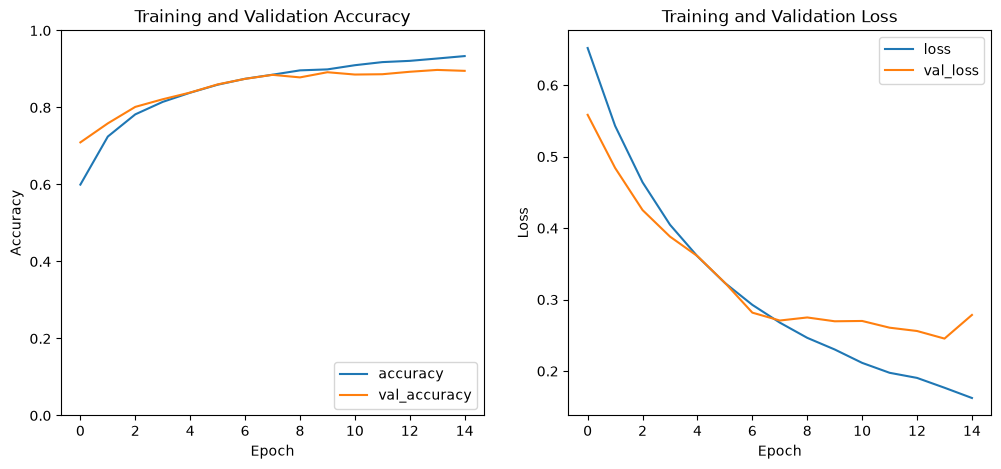

782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step

Confusion Matrix:
[[11700   799]
 [  633 11865]]


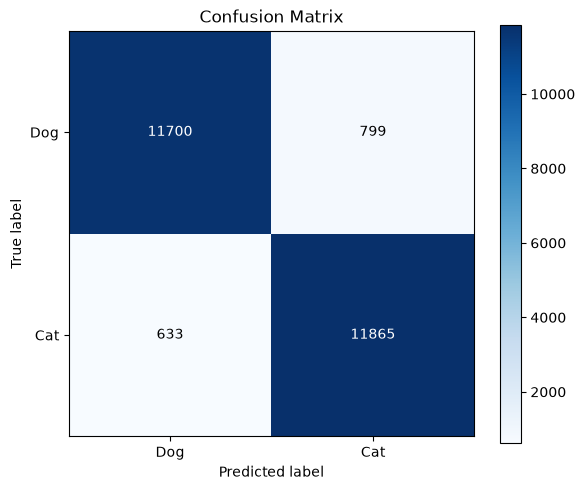

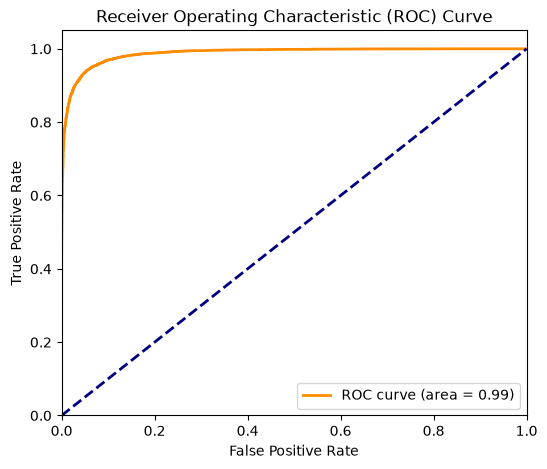

In [18]:
model.summary()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np # numpy is already imported as np earlier

# Plot training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Get predictions for confusion matrix and ROC
y_pred_proba = model.predict(X).ravel() # .ravel() to flatten to 1D array
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y)))
CATEGORIES = ["Dog", "Cat"]
plt.xticks(tick_marks, CATEGORIES)
plt.yticks(tick_marks, CATEGORIES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
fmt = 'd'
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], fmt),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [19]:
# just inserted this 9/18/2026
from sklearn.metrics import classification_report, confusion_matrix

# Test Accuracy / Test Loss - genuine, since X_test/y_test were held out before training
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# Precision / Recall / F1 (macro avg) - on the held-out test set
y_test_pred_proba = model.predict(X_test).ravel()
y_test_pred = (y_test_pred_proba > 0.5).astype(int)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=CATEGORIES, digits=4))

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))


Test Accuracy: 0.9461
Test Loss:     0.1408
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step

Classification Report (Test Set):
              precision    recall  f1-score   support

         Dog     0.9534    0.9381    0.9457      1875
         Cat     0.9391    0.9541    0.9466      1875

    accuracy                         0.9461      3750
   macro avg     0.9462    0.9461    0.9461      3750
weighted avg     0.9462    0.9461    0.9461      3750

Confusion Matrix (Test Set):
[[1759  116]
 [  86 1789]]


In [20]:
import sys
print("Python being used:", sys.executable)

try:
    import h5py
    print("h5py version:", h5py.__version__)
    print("h5py location:", h5py.__file__)
except ImportError as e:
    print("h5py still not found:", e)

Python being used: C:\Users\Victus\anaconda3\envs\Activity_01\python.exe
h5py version: 3.16.0
h5py location: C:\Users\Victus\anaconda3\envs\Activity_01\Lib\site-packages\h5py\__init__.py


In [21]:
import tensorflow as tf

# Define the filename for your model
model_filename = 'dog_cat_classifier.keras' # .keras is the recommended extension for Keras models

# Save the model
model.save(model_filename)
print(f"Model saved to {model_filename}")

# To load the model later (you can do this in a new session or script)
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# You can then use the loaded_model for predictions or further evaluation
# For example, let's make predictions with the loaded model and compare
loaded_model_predictions = loaded_model.predict(X)
print("\nExample predictions from loaded model:")
print(loaded_model_predictions[:5])


Model saved to dog_cat_classifier.keras
Model loaded from dog_cat_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step

Example predictions from loaded model:
[[4.1532409e-03]
 [6.5781013e-04]
 [3.2054102e-03]
 [9.9620253e-01]
 [6.2555247e-03]]


##### Prediction Inferencem

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predictions for the test samples:
Sample 1: Predicted Class = Dog (Probability: 0.42%) 
Sample 2: Predicted Class = Dog (Probability: 0.07%) 
Sample 3: Predicted Class = Dog (Probability: 0.32%) 
Sample 4: Predicted Class = Cat (Probability: 99.62%) 
Sample 5: Predicted Class = Dog (Probability: 0.63%) 


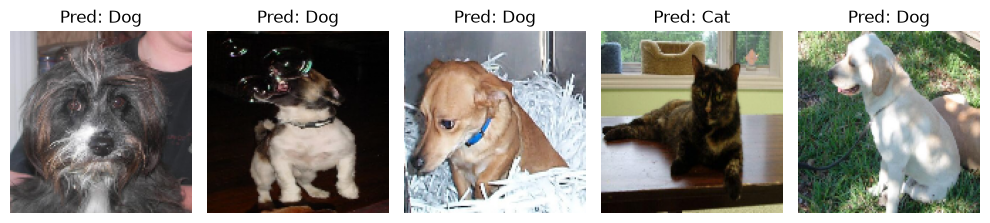

In [22]:
# Select a small subset of data for inference (e.g., the first 5 samples)
# In a real scenario, this would be entirely new, unseen test data.
test_samples = X[:5]

# Make predictions using the loaded model
inference_predictions = loaded_model.predict(test_samples)

print("Predictions for the test samples:")
for i, prediction in enumerate(inference_predictions):
    # Assuming binary classification with sigmoid output, values close to 1 are 'Cat', close to 0 are 'Dog'
    predicted_class = 'Cat' if prediction[0] > 0.5 else 'Dog'
    probability = prediction[0] * 100
    print(f"Sample {i+1}: Predicted Class = {predicted_class} (Probability: {probability:.2f}%) ")

# Optionally, display the images and their predictions
plt.figure(figsize=(10, 4))
for i in range(min(5, len(test_samples))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_samples[i][..., ::-1])  # reverses the last axis (channels): BGR -> RGB, no dtype issues
    predicted_class = 'Cat' if inference_predictions[i][0] > 0.5 else 'Dog'
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()